# Implement folder Planck equation
Work on hi and si

# Implement folder Planck equation
Work on hi and si

In [17]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")


In [2]:
p_let=0.05
p_aa=0.05
p_sil=0.9
mu_M=-0.5
sigma_M=0.3
S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
E_a=2                         # Ag-gate threshold
kBT=1.0                         # thermal factor
N_i=2500  
N_max=2500
mu_i=0.0 
sigma_i=0.5
p_diff=0.10
    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)

In [3]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=None,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=2500,  N_max=2500,
    # grid / time ----------------------------------------------------------
    h_min=-7.0, h_max=7.0, d_h=0.1,
    T=10.0,  dt=0.01,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h


    print('D=',D)

    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  = (C_broad * eE).sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        np.maximum(rho, 0.0, out=rho)                    # clip negatives

        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [4]:
def run_fp(S_mat, get_C, *, T=20.0, verbose=False):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        S_mat=S_mat, get_C=get_C, T=T, verbose=verbose
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = S_mat.shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")
    E_full    = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = (C_vec.reshape((n_A,) + (1,)*N_h) * np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    S_torch = torch.tensor(S_mat, dtype=torch.float64)
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t):
            E_v = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t*torch.exp((E_v-E_a)/kBT)).sum()
            P_Ag = P_Ag / (1.+P_Ag)
            Phi  = (C_t*torch.exp(E_v/kBT)).sum()
            P_T  = Phi / (Phi + Phi_b/C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np):
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        S_mat=S_mat, get_C=get_C
    )


In [5]:
def make_grad_Gamma(fp_ctx):
    times, grads = fp_ctx["times"], fp_ctx["grad_list"]
    def grad(h, t):
        if t <= times[0]:  return grads[0](h)
        if t >= times[-1]: return grads[-1](h)
        hi = np.searchsorted(times, t)
        lo = hi - 1
        w  = (t-times[lo])/(times[hi]-times[lo])
        return (1.-w)*grads[lo](h) + w*grads[hi](h)
    return grad
def solve_optimal_trajectory(hf, fp_ctx, *, mesh=300, max_nodes=2_0000, plot=False):
    times  = fp_ctx["times"]
    grad_G = make_grad_Gamma(fp_ctx)
    hf     = np.repeat(hf, 2) if np.isscalar(hf) else np.asarray(hf,float)

    def ode(t,y):
        h, v = y[:2], y[2:]
        a    = np.empty_like(h)
        for j, tj in enumerate(t):
            a[:,j] = -D*grad_G(h[:,j], tj)
        return np.vstack((v, a))

    def bc(ya,yb):
        return np.hstack((ya[:2], yb[:2]-hf))

    t_mesh = np.linspace(times[0], times[-1], mesh)
    y_guess= np.zeros((4,mesh))
    for i in range(2):
        y_guess[i] = hf[i]*(t_mesh-t_mesh[0])/(t_mesh[-1]-t_mesh[0])

    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=max_nodes)
    if not sol.success: raise RuntimeError(sol.message)

    if plot:
        plt.figure(figsize=(6,3))
        plt.plot(sol.x, sol.y[0], label=r"$h_1$")
        plt.plot(sol.x, sol.y[1], label=r"$h_2$")
        plt.xlabel("time"); plt.ylabel("shape"); plt.legend(); plt.tight_layout(); plt.show()
    return sol
def compute_least_action(sol, fp_ctx, *, baseline=True, verbose=False):
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    n_A     = S_mat.shape[1]

    S_T     = torch.tensor(S_mat, dtype=torch.float64)
    v_vec   = f_aa*mu_M*np.ones(2)

    def Γ(t,h_np):
        k   = np.argmin(np.abs(times - t))
        omega = omegas[k];  Phi_b = Phi_bar[k]
        C_vec = np.array([get_C(float(times[k]), v) for v in range(n_A)])
        h_t   = torch.tensor(h_np, dtype=torch.float64)
        C_t   = torch.tensor(C_vec, dtype=torch.float64)
        E_v   = torch.mv(S_T.T, h_t)
        PAg   = (C_t*torch.exp((E_v-E_a)/kBT)).sum()
        PAg   = PAg / (1.+PAg)
        Phi   = (C_t*torch.exp(E_v/kBT)).sum()
        PT    = Phi / (Phi + Phi_b/C_t.sum())
        return (lam + torch.log(PAg) + torch.log(PT) - omega).item()

    t_mesh = sol.x
    h_opt  = sol.y[:2].T
    v_opt  = sol.y[2:].T

    def S_of(h,v):
        g  = np.array([Γ(ti,hi) for ti,hi in zip(t_mesh,h)])
        kin= np.sum((v-v_vec)**2,1)/(2*D)
        return -np.trapz(g-kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)
    if not baseline:
        if verbose: print(f"S_opt={S_opt:.6e}")
        return S_opt

    slope = h_opt[-1]/(t_mesh[-1]-t_mesh[0])
    h_lin = (t_mesh[:,None]-t_mesh[0])*slope[None,:]
    v_lin = np.tile(slope, (len(t_mesh),1))
    S_lin = S_of(h_lin, v_lin)

    if verbose:
        print(f"S_opt={S_opt:.6e}  S_lin={S_lin:.6e}  ΔS={S_lin-S_opt:.6e}")
    return S_opt, S_lin


In [6]:
# ---------------------------------------------------------------------
#  plot_fp_density_time_x(fp_ctx, sol=None,
#                         h1_window=(0,2), disp_step=0.4, cmap='viridis')
# ---------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_x(fp_ctx, sol=None, *,
                           h1_window=None, disp_step=0.4, cmap="viridis"):

    axes   = fp_ctx["axes"]
    times  = fp_ctx["times"]
    rho_t  = fp_ctx["rho_t"]

    h1_axis, h2_axis = axes
    d_h  = h1_axis[1] - h1_axis[0]

    # ---- marginal ρ(t,h₁) ------------------------------------------
    rho_marg = rho_t.sum(axis=-1) * d_h          # (n_snap , n_h1)

    # ---- select display rows (h₁) ----------------------------------
    if h1_window is None:
        h1_min, h1_max = h1_axis[0], h1_axis[-1]
    else:
        h1_min, h1_max = h1_window
    mask   = (h1_axis >= h1_min) & (h1_axis <= h1_max)
    stride = max(1, int(round(disp_step / d_h)))
    idx    = np.where(mask)[0][::stride]

    h1_disp   = h1_axis[idx]
    rho_disp  = rho_marg[:, idx].T              # shape (n_h1_disp , n_snap)

    # ---- build extent so that pixels align with bin centres --------
    t0, tf   = times[0], times[-1]
    dt       = times[1] - times[0] if len(times) > 1 else 1.0
    extent   = (t0 - dt/2, tf + dt/2,
                h1_disp[0] - d_h/2, h1_disp[-1] + d_h/2)

    # ---- plot -------------------------------------------------------
    plt.figure(figsize=(6,4))
    im = plt.imshow(rho_disp,
                    origin="lower",
                    extent=extent,
                    aspect="auto",
                    cmap=cmap)
    plt.colorbar(im, label=r"$\rho(t,h_1)$  (marginalised\ over\ $h_2$)")
    plt.xlabel("time")
    plt.ylabel(r"$h_1$")

    # optional: overlay least‑action h₁(t)
    if sol is not None:
        plt.plot(sol.x, sol.y[0], color="red", lw=1.4,
                 label="least‑action $h_1(t)$")
        plt.legend()

    plt.title("Fokker–Planck density vs. time (h₂ integrated out)")
    plt.tight_layout()
    plt.show()


D= 0.017202216066481996


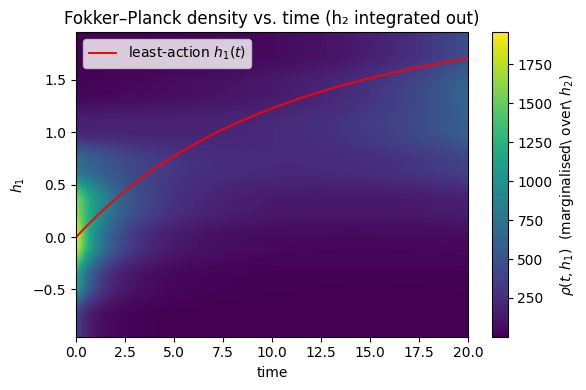

S_opt=1.321965e+01  S_lin=1.454683e+01  ΔS=1.327178e+00


In [7]:
# run FP at C=5 and build context
def get_C(t,v): return 5.0
S_mat = np.array([[1.],[1.]], dtype=float)
fp_ctx = run_fp(S_mat, get_C, T=20.0, verbose=False)
fp_ctx["get_C"] = get_C          # keep callable inside context

# solve least‑action trajectory to (h₁,h₂) = (1.7,1.7)
sol = solve_optimal_trajectory([1.7,1.7], fp_ctx)

# plot density heat‑map with trajectory overlay
plot_fp_density_time_x(fp_ctx, sol,
                       h1_window=(-1,2),   # show h₁ from 0 to 2
                       disp_step=0.4)
S,_=compute_least_action(sol, fp_ctx, verbose=True)

In [50]:
import torch

def compute_least_action_torch(
    sol,
    fp_ctx,
    C_param,                     # ←  passed in, NOT created here
    *,
    baseline: bool = True,
    verbose: bool = False,
):
    """
    S_opt,  dS/dC  = compute_least_action_torch(sol, fp_ctx, C_param, ...)

    Parameters
    ----------
    C_param  : torch.Tensor
        • shape ()  → one global concentration shared by all time‑slices
        • shape (n_times,) → independent value per FP snapshot
        In either case, requires_grad must be True.
    baseline : if True also computes linear‑trajectory action (ignored here)
    verbose  : print diagnostics (last 10 Ω and Φ̄ values)

    Returns
    -------
    S_opt   : torch scalar (action along the optimal trajectory)
    dS_dC   : torch scalar –  ∂S_opt / ∂C_param   (sum over all elements
               if C_param is a vector, so you can treat it as a single LR step)
    """
    # ------------------------------------------------------------------
    # 0 · setup / bookkeeping
    # ------------------------------------------------------------------
    device = C_param.device
    times  = torch.tensor(fp_ctx["times"],  dtype=torch.float64, device=device)
    n_times = len(times)

    # allow scalar or vector C_param
    if C_param.ndim == 0:                   # global concentration
        C_vec_t = C_param.expand(n_times)   # shares grad with scalar
    elif len(C_param) == n_times:           # per‑time values
        C_vec_t = C_param
    else:
        raise ValueError("C_param has incompatible length")

    # ------------------------------------------------------------------
    # 1 · data from FP
    # ------------------------------------------------------------------
    omegas_fp = torch.tensor(fp_ctx["omegas"],  dtype=torch.float64, device=device)
    Phi_fp    = torch.tensor(fp_ctx["Phi_bar"], dtype=torch.float64, device=device)
    S_mat     = torch.tensor(fp_ctx["S_mat"],    dtype=torch.float64, device=device)
    rho_np    = fp_ctx["rho_t"]
    axes_np   = fp_ctx["axes"]

    N_h, n_A  = S_mat.shape
    d_h       = axes_np[0][1] - axes_np[0][0]
    dH        = d_h ** N_h

    # constant energy grids
    axes_t = [torch.tensor(ax, dtype=torch.float64, device=device) for ax in axes_np]
    H_mesh = torch.meshgrid(*axes_t, indexing="ij")             # list len N_h
    H_stack= torch.stack(H_mesh, dim=0)                         # (N_h,*grid)
    E_stack= torch.tensordot(S_mat.T, H_stack, dims=([1],[0]))  # (n_A,*grid)
    exp_E      = torch.exp(E_stack / kBT)
    exp_Eshift = torch.exp((E_stack - E_a) / kBT)
    sum_exp_E      = exp_E.sum(dim=0)
    sum_exp_Eshift = exp_Eshift.sum(dim=0)

    rho_t = [torch.tensor(r, dtype=torch.float64, device=device) for r in rho_np]

    # ------------------------------------------------------------------
    # 2 · recompute Φ̄(t_k) and Ω(t_k)
    # ------------------------------------------------------------------
    Phi_bar = torch.empty_like(times)
    Omega   = torch.empty_like(times)

    for k in range(n_times):
        Ck   = C_vec_t[k]
        Phi_grid   = Ck * sum_exp_E
        Phi_bar_k  = (rho_t[k] * Phi_grid).sum() * dH / (rho_t[k].sum() * dH)
        Phi_bar[k] = Phi_bar_k

        numer_PAg = Ck * sum_exp_Eshift
        P_Ag_grid = numer_PAg / (1.0 + numer_PAg)

        P_T_grid  = Phi_grid / (Phi_grid + Phi_bar_k / (n_A * Ck))
        log_sel   = torch.log(P_Ag_grid) + torch.log(P_T_grid)

        N_pop     = rho_t[k].sum() * dH
        avg_log   = (rho_t[k] * log_sel).sum() * dH / (rho_t[k].sum() * dH)

        Omega[k]  = torch.where(
            N_pop >= N_max,
            torch.maximum(torch.tensor(0.0, dtype=torch.float64, device=device),
                          lam + avg_log),
            torch.tensor(0.0, dtype=torch.float64, device=device)
        )

    # ------------------------------------------------------------------
    # 3 · optimal trajectory from SciPy
    # ------------------------------------------------------------------
    t_mesh = torch.tensor(sol.x,        dtype=torch.float64, device=device)
    h_opt  = torch.tensor(sol.y[:2].T,  dtype=torch.float64, device=device)
    v_opt  = torch.tensor(sol.y[2:].T,  dtype=torch.float64, device=device)

    v_pref = torch.full((2,), f_aa * mu_M, dtype=torch.float64, device=device)

    def idx(t):
        return torch.argmin(torch.abs(times - t))

    g_vals = torch.empty_like(t_mesh)
    kin    = torch.empty_like(t_mesh)

    for j, t_j in enumerate(t_mesh):
        k       = idx(t_j)
        Ck      = C_vec_t[k]
        C_vec   = Ck.expand(n_A)

        E_v = torch.mv(S_mat.T, h_opt[j])
        P_Ag = (C_vec * torch.exp((E_v - E_a) / kBT)).sum()
        P_Ag = P_Ag / (1. + P_Ag)

        Phi  = (C_vec * torch.exp(E_v / kBT)).sum()
        P_T  = Phi / (Phi + Phi_bar[k] / (n_A * Ck))

        g_vals[j] = lam + torch.log(P_Ag) + torch.log(P_T) - Omega[k]
        kin[j]    = ((v_opt[j] - v_pref).pow(2).sum()) / (2. * D)

    S_opt = -torch.trapz(g_vals - kin, t_mesh)

    # already have S_opt
    if baseline:
        # ----- linear trajectory 0 → h_d ---------------------------------
        h_d    = h_opt[-1]                              # endpoint
        T_tot  = t_mesh[-1] - t_mesh[0]                 # horizon
        slope  = h_d / T_tot                            # constant velocity

        h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope  # (m,2)
        v_lin  = slope.expand_as(h_lin)                 # same shape

        g_lin  = torch.empty_like(t_mesh)
        kin_lin= torch.empty_like(t_mesh)

        for j, t_j in enumerate(t_mesh):
            k = idx(t_j)                                # snapshot index
            Ck = C_vec_t[k]
            C_vec = Ck.expand(n_A)

            E_v = torch.mv(S_mat.T, h_lin[j])
            P_Ag = (C_vec * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)

            Phi  = (C_vec * torch.exp(E_v / kBT)).sum()
            P_T  = Phi / (Phi + Phi_bar[k] / (n_A * Ck))

            g_lin[j]   = lam + torch.log(P_Ag) + torch.log(P_T) - Omega[k]
            kin_lin[j] = ((v_lin[j] - v_pref).pow(2).sum()) / (2. * D)

        S_lin = -torch.trapz(g_lin - kin_lin, t_mesh)
        print('Slin: ', S_lin)
    else:
        S_lin = None

    

    # ------------------------------------------------------------------
    # 5 · diagnostics
    # ------------------------------------------------------------------
    if verbose:
        print("Ω  recomputed (last 10):", Omega[-10:].detach().cpu().numpy())
        print("Ω_FP stored    (last 10):", omegas_fp[-10:].detach().cpu().numpy())
        print("Φ̄ recomputed (last 10):", Phi_bar[-10:].detach().cpu().numpy())
        print("Φ̄_FP stored   (last 10):", Phi_fp[-10:].detach().cpu().numpy())

    return S_opt, None

In [25]:
S_mat = np.array([[1.], [1.]], dtype=float)   # two shape coords, 1 Ag
hf     = [1.7, 1.7]  
c=20
def get_C(t, v):
        return c
fp_ctx = run_fp(S_mat, get_C, T=20, verbose=False)

fp_ctx["get_C"] = get_C

# --- 2. least‑action path to hf ----------------------------
sol = solve_optimal_trajectory(hf, fp_ctx, plot=False)


# C_param = torch.tensor(float(10), dtype=torch.float64, requires_grad=True)
# --- 1. fresh FP run with the *current* C -------------------
                                             # scalar float
# --- 3. action + gradient wrt C ----------------------------
init_C=c
times      = torch.tensor(fp_ctx["times"],  dtype=torch.float64)

n_times    = len(times)
C_param = torch.nn.Parameter(
        torch.full((n_times,), init_C, dtype=torch.float64)
    )
S_opt, dS_dC = compute_least_action_torch(
    sol, fp_ctx, C_param=C_param, baseline=False, verbose=True)
print('torch',S_opt)
S_opt_np = compute_least_action(sol, fp_ctx, baseline=False, verbose=False)
print('np',S_opt_np)



D= 0.017202216066481996
grad torch.Size([2001])
Ω  recomputed (last 10): [0.33595181 0.33599386 0.33603589 0.33607789 0.33611986 0.33616181
 0.33620372 0.33624562 0.33628748 0.33632932]
Ω_FP stored    (last 10): [0.33590973 0.33595181 0.33599386 0.33603589 0.33607789 0.33611986
 0.33616181 0.33620372 0.33624562 0.33628748]
Φ̄ recomputed (last 10): [101.20305514 101.25452399 101.30601033 101.35751419 101.40903555
 101.46057443 101.51213084 101.56370477 101.61529624 101.66690524]
Φ̄_FP stored   (last 10): [101.20305514 101.25452399 101.30601033 101.35751419 101.40903555
 101.46057443 101.51213084 101.56370477 101.61529624 101.66690524]
S_opt = 1.125521e+01   dS/dC = 1.414e-01
torch tensor(11.2552, dtype=torch.float64, grad_fn=<NegBackward0>)
np 11.252828521405812


# Different concentrations

In [61]:
import numpy as np
import torch, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"   # avoid Intel‑/PyTorch OMP clash
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
# optimise_multiC_20  –  20 independent concentrations on [0,20] s
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0=5.0,                   # initial value for every bin
    lr=0.2,                   # learning‑rate
    n_steps=25, tol=1e-4,     # GD iterations / stop crit
    T=20.0,                   # FP horizon in seconds
    verbose=True
):
    """
    Learns 20 parameters C_bins[0..19] where
        C(t) = C_bins[ floor(t) ]   for 0 ≤ t ≤ 20.

    Internally the FP solver still receives a length‑n_times vector
    (n_times ≈ 2 000), but all copies reference the same 20 leaves, so
    gradients accumulate automatically.
    """
    # ① obtain the FP snapshot grid once
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.array(fp_probe["times"])   # len n_times
    n_times  = len(times_np)

    # mapping snapshot index → integer‑second bin  (0..19)
    bin_idx = torch.tensor(
        np.clip(np.floor(times_np).astype(int), 0, 19), dtype=torch.long
    )

    # 20 learnable scalars
    C_bins = torch.full((20,), float(C0), dtype=torch.float64, requires_grad=True)

    hist_C, hist_S = [], []

    for it in range(n_steps):

        # ------------------------------------------------ full per‑snapshot tensor
        C_param = C_bins[bin_idx]          # shares grad with C_bins

        # detached array for FP (outside autograd graph)
        C_det = C_bins.detach().cpu().numpy()

        def get_C_piece(t, v, C_arr=C_det):
            idx = int(t)
            return float(C_arr[19 if idx > 19 else idx])

        # ② fresh FP simulation
        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)

        def get_C_granular(t, v, C_arr=C_param):
            idx = int(t)
            return float(C_arr[idx])
        fp_ctx["get_C"] = get_C_granular

        # ③ least‑action trajectory (mesh == snapshot grid)
        sol = solve_optimal_trajectory(
            hf, fp_ctx, mesh=n_times, plot=False
        )

        # ④ action (compute_least_action_torch remains unchanged)
        S_opt, _ = compute_least_action_torch(
            sol, fp_ctx, C_param=C_param, baseline=False, verbose=True
        )

        # back‑prop once to fill C_bins.grad
        if C_bins.grad is not None:
            C_bins.grad.zero_()
        S_opt.backward()

        grad_bins = C_bins.grad.detach().clone()  # shape (20,)
        print('C_bins', C_bins)

        print('grad_bins', grad_bins)

        # ------------------------------------------------ bookkeeping
        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())
        gmax = grad_bins.abs().max().item()

        if verbose:
            print(f"iter {it:2d}   "
                  f"S={S_opt.item():.6e}   max|∂S/∂C_bin|={gmax:.3e}")

        # convergence
        if gmax < tol:
            if verbose:
                print("‣ all |∂S/∂C_bin| below tolerance — stop.")
            break

        # ⑤ gradient step
        with torch.no_grad():
            C_bins -= lr * grad_bins
            C_bins.clamp_(min=1e-4)

        C_bins.grad = None                    # clear for next loop

    return (hist_C, hist_S), C_bins


In [67]:
S_mat = np.array([[1.], [1.]], dtype=float)   # two h‑coords, one antigen
hf    = [1.7, 1.7]

(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=5., lr=5, n_steps=8, tol=1e-4, verbose=True
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))


D= 0.017202216066481996
D= 0.017202216066481996
Ω  recomputed (last 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Ω_FP stored    (last 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Φ̄ recomputed (last 10): [100.70315027 100.79527754 100.88747774 100.97975091 101.07209712
 101.16451644 101.25700892 101.34957463 101.44221362 101.53492597]
Φ̄_FP stored   (last 10): [100.70315027 100.79527754 100.88747774 100.97975091 101.07209712
 101.16451644 101.25700892 101.34957463 101.44221362 101.53492597]
C_bins tensor([5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5., 5.,
        5., 5.], dtype=torch.float64, requires_grad=True)
grad_bins tensor([-0.1485, -0.1284, -0.1099, -0.0944, -0.0816, -0.0714, -0.0632, -0.0566,
        -0.0513, -0.0471, -0.0437, -0.0410, -0.0388, -0.0371, -0.0357, -0.0347,
        -0.0340, -0.0335, -0.0333, -0.0334], dtype=torch.float64)
iter  0   S=1.321933e+01   max|∂S/∂C_bin|=1.485e-01
D= 0.017202216066481996
Ω  recomputed (last 10): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Ω_FP s

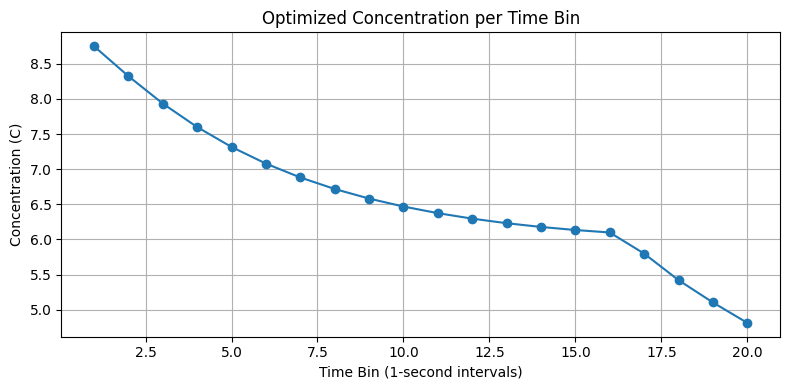

In [68]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# If C20_final is a torch.Tensor of shape (20,)
C_np = C_final.detach().cpu().numpy()

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 21), C_np, marker='o')
plt.title("Optimized Concentration per Time Bin")
plt.xlabel("Time Bin (1-second intervals)")
plt.ylabel("Concentration (C)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [69]:
C0=5
T=20
fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
times_np = np.array(fp_probe["times"])   # len n_times
n_times  = len(times_np)

# mapping snapshot index → integer‑second bin  (0..19)
C_bins = C_final

times_np = np.array(fp_probe["times"])   # len n_times
n_times  = len(times_np)

# mapping snapshot index → integer‑second bin  (0..19)
bin_idx = torch.tensor(
np.clip(np.floor(times_np).astype(int), 0, 19), dtype=torch.long
)

        # ------------------------------------------------ full per‑snapshot tensor
C_param = C_bins[bin_idx]          # shares grad with C_bins

        # detached array for FP (outside autograd graph)
C_det = C_bins.detach().cpu().numpy()


def get_C_piece(t, v, C_arr=C_det):
    idx = int(t)
    return float(C_arr[19 if idx > 19 else idx])

# ② fresh FP simulation
fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)

D= 0.017202216066481996
D= 0.017202216066481996


In [70]:
C_param

tensor([8.7505, 8.7505, 8.7505,  ..., 4.8135, 4.8135, 4.8135],
       dtype=torch.float64, grad_fn=<IndexBackward0>)

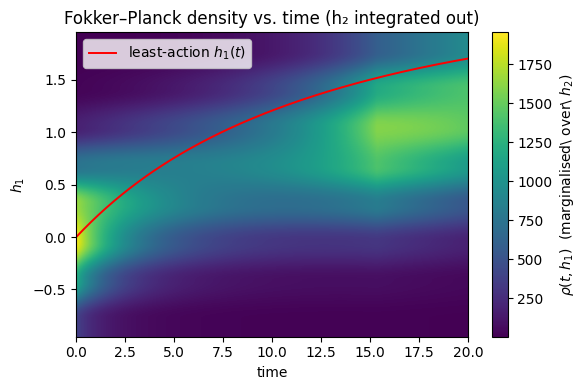

Slin:  tensor(11.8265, dtype=torch.float64, grad_fn=<NegBackward0>)
Ω  recomputed (last 10): [0.12336594 0.12349257 0.12361903 0.1237453  0.1238714  0.12399732
 0.12412306 0.12424863 0.12437402 0.12449923]
Ω_FP stored    (last 10): [0.12323913 0.12336594 0.12349257 0.12361903 0.1237453  0.1238714
 0.12399732 0.12412306 0.12424863 0.12437402]
Φ̄ recomputed (last 10): [74.86236253 74.94252279 75.02274353 75.10302481 75.18336667 75.26376919
 75.34423241 75.4247564  75.50534122 75.58598692]
Φ̄_FP stored   (last 10): [74.86236253 74.94252279 75.02274353 75.10302481 75.18336667 75.26376919
 75.34423241 75.4247564  75.50534122 75.58598692]
Sopt tensor(11.4583, dtype=torch.float64, grad_fn=<NegBackward0>)


In [71]:
# run FP at C=5 and build context
# fp_ctx["get_C"] = get_C_piece          # keep callable inside context
def get_C_granular(t, v, C_arr=C_param):
        idx = int(t)
        return float(C_arr[idx])
fp_ctx["get_C"] = get_C_granular
# solve least‑action trajectory to (h₁,h₂) = (1.7,1.7)
sol = solve_optimal_trajectory([1.7,1.7], fp_ctx)

# plot density heat‑map with trajectory overlay
plot_fp_density_time_x(fp_ctx, sol,
                       h1_window=(-1,2),   # show h₁ from 0 to 2
                       disp_step=0.4)
S,_=compute_least_action_torch(sol, fp_ctx, C_param, verbose=True)
print('Sopt', S)

In [72]:
C_param.shape

torch.Size([2001])